In [1]:
# Task 1: Time series analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

In [2]:
# Load and combine the two churn files
df80 = pd.read_csv("churn-bigml-80.csv")
df20 = pd.read_csv("churn-bigml-20.csv")
df = pd.concat([df80, df20], ignore_index = True)
df["Churn"] = df["Churn"].astype(int)
print(df.head())

  State  Account length  Area code International plan Voice mail plan  \
0    KS             128        415                 No             Yes   
1    OH             107        415                 No             Yes   
2    NJ             137        415                 No              No   
3    OH              84        408                Yes              No   
4    OK              75        415                Yes              No   

   Number vmail messages  Total day minutes  Total day calls  \
0                     25              265.1              110   
1                     26              161.6              123   
2                      0              243.4              114   
3                      0              299.4               71   
4                      0              166.7              113   

   Total day charge  Total eve minutes  Total eve calls  Total eve charge  \
0             45.07              197.4               99             16.78   
1             27.47   

In [3]:
# Build the sequence
df["tenure_bucket"] = (df["Account length"] // 5) * 5
bucketed = df.groupby("tenure_bucket").agg(churn_rate = ("Churn", "mean"), n = ("Churn", "size"))
bucketed = bucketed[bucketed["n"] >= 5]

series = bucketed["churn_rate"]
series.index.name = "Tenure bucket (days)"
series.name = "Churn rate"
print(f"Sequence length: {len(series)} tenure buckets")

Sequence length: 42 tenure buckets


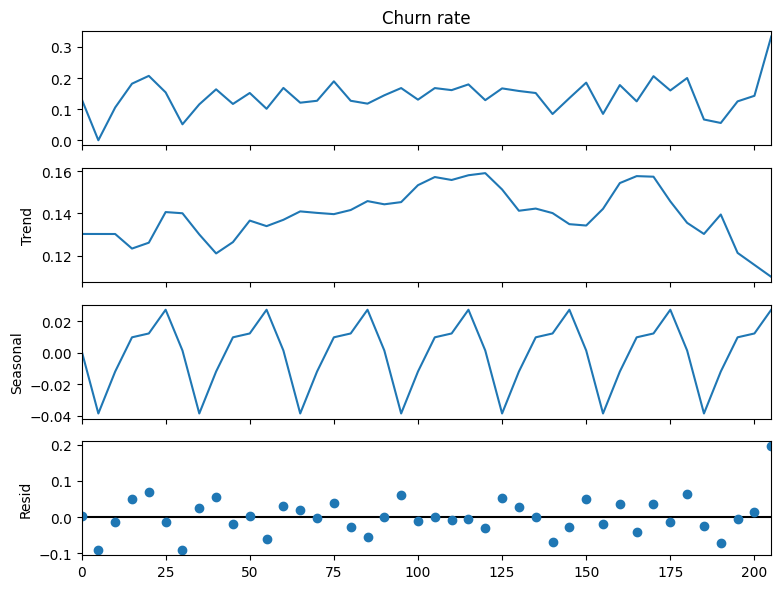

In [5]:
# Decompose into trend / seasonality / residual
decomposition = seasonal_decompose(series, period = 6, model = "additive", extrapolate_trend = "freq")
fig = decomposition.plot()
fig.set_size_inches(8, 6)
plt.tight_layout()
plt.savefig("decomposition.png", dpi = 150)
plt.show()
plt.close()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


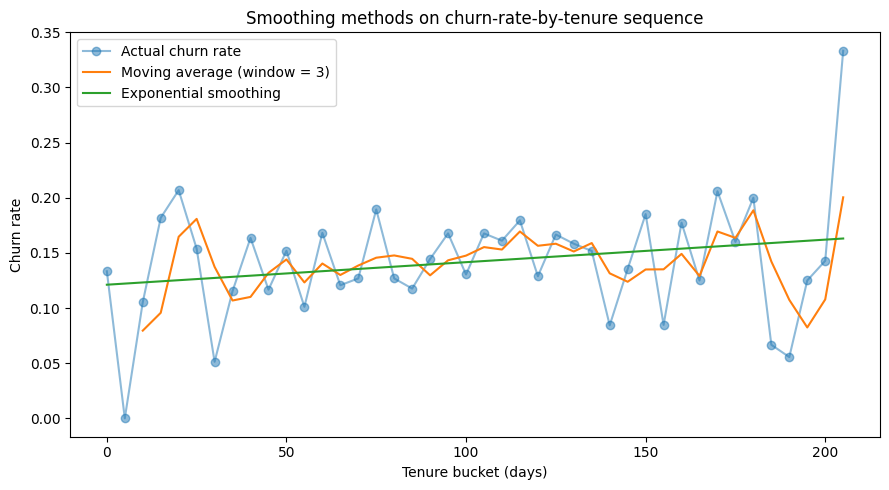

In [6]:
# 4. Moving average and exponential smoothing
moving_avg = series.rolling(window = 3).mean()
exp_smooth_model = ExponentialSmoothing(series, trend = "add").fit()
exp_smooth_fitted = exp_smooth_model.fittedvalues

plt.figure(figsize = (9, 5))
plt.plot(series.index, series.values, label = "Actual churn rate", alpha = 0.5, marker = "o")
plt.plot(moving_avg.index, moving_avg.values, label = "Moving average (window = 3)")
plt.plot(exp_smooth_fitted.index, exp_smooth_fitted.values, label = "Exponential smoothing")
plt.xlabel("Tenure bucket (days)")
plt.ylabel("Churn rate")
plt.title("Smoothing methods on churn-rate-by-tenure sequence")
plt.legend()
plt.tight_layout()
plt.savefig("smoothing.png", dpi = 150)
plt.show()
plt.close()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give

ARIMA(1,1,1) RMSE on test set: 0.0812


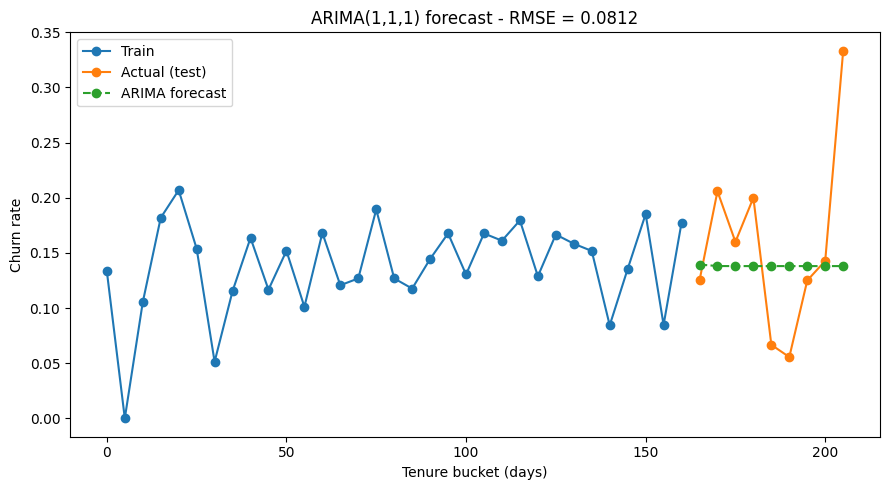

In [8]:
# Train/test split and ARIMA forecast
train_size = int(len(series) * 0.8)
train, test = series.iloc[:train_size], series.iloc[train_size:]

arima_model = ARIMA(train, order = (1, 1, 1)).fit()
forecast = arima_model.forecast(steps = len(test))

rmse = np.sqrt(mean_squared_error(test, forecast))
print(f"ARIMA(1,1,1) RMSE on test set: {rmse:.4f}")

plt.figure(figsize = (9, 5))
plt.plot(train.index, train.values, label = "Train", marker = "o")
plt.plot(test.index, test.values, label = "Actual (test)", marker = "o")
plt.plot(test.index, forecast.values, label = "ARIMA forecast", linestyle = "--", marker = "o")
plt.xlabel("Tenure bucket (days)")
plt.ylabel("Churn rate")
plt.title(f"ARIMA(1,1,1) forecast - RMSE = {rmse:.4f}")
plt.legend()
plt.tight_layout()
plt.savefig("arima_forecast.png", dpi = 150)
plt.show()
plt.close()